## Workshop 1 je crois

In [ ]:
# 2) Upgrade pip tooling
# python -m pip install --upgrade pip setuptools wheel

In [ ]:
# 3) Install OpenCV from PyPI (choose ONE)
# pip install opencv-python          # main package (most users)

In [ ]:
import cv2 as cv
import numpy as np

In [ ]:
print("OpenCV:", cv.__version__)
img = np.zeros((120, 650, 3), dtype=np.uint8)
cv.putText(img, "Houlahup barbatruc", (10, 80), cv.FONT_HERSHEY_SIMPLEX, 2, (255,255,255), 3)
# If you installed a non-headless build, you can display a window:
# cv.imshow("hello", img); cv.waitKey(0)
# Always safe (headless or not): save to file
cv.imwrite("hello.png", img)

OpenCV: 4.13.0


True

## Workshop 2

In [ ]:
from PIL import Image
import numpy as np
imgpil = Image.open("image.jpg")
img = np.array(imgpil)

In [ ]:
img.shape

(324, 1275, 4)

## Permet d'afficher la valeur d'un pixel

In [ ]:
img[200, 100]

array([251, 238, 211, 255], dtype=uint8)

## Permet de changer la valeur d'un pixel

In [ ]:
img[200, 100] = (125, 30, 255)

## Supprimer l'alpha d'une image

In [ ]:
from PIL import Image
import sys

def remove_alpha(input_path, output_path, background_color=(255, 255, 255)):
    """
    Supprime le canal alpha d'une image et remplace la transparence par une couleur de fond.
    
    :param input_path: Chemin de l'image source
    :param output_path: Chemin de l'image de sortie
    :param background_color: Couleur de fond (R, G, B)
    """
    try:
        img = Image.open(input_path)

        # Si l'image a un canal alpha
        if img.mode in ("RGBA", "LA") or (img.mode == "P" and "transparency" in img.info):
            # Créer un fond uni
            background = Image.new("RGB", img.size, background_color)
            # Coller l'image par-dessus en utilisant l'alpha comme masque
            background.paste(img, mask=img.split()[-1])
            img = background
        else:
            # Convertir en RGB si nécessaire
            img = img.convert("RGB")

        img.save(output_path)
        print(f"Image sauvegardée sans alpha : {output_path}")

    except Exception as e:
        print(f"Erreur : {e}", file=sys.stderr)

# Exemple d'utilisation
remove_alpha("image.jpg", "image_sans_alpha.jpg", background_color=(255, 255, 255))

Image sauvegardée sans alpha : image_sans_alpha.jpg


In [ ]:
img = Image.open("image_sans_alpha.jpg")

## Création de fonctions filtres

In [ ]:
def filtre_rouge(img_orig):
    im = np.copy(img_orig) # copie de l'original
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            r, v, b = im[i, j]
            im[i, j] = (r, 0, 0)
    return im


def filtre_vert(img_orig):
    im = np.copy(img_orig) # toujours une copie
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            r, v, b = im[i, j]
            im[i, j] = (0, v, 0)
    return im


def filtre_bleu(img_orig):
    im = np.copy(img_orig) # on refait une copie de l'original
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            r, v, b = im[i, j]
            im[i, j] = (0, 0, b)
    return im



imgpil = Image.fromarray(filtre_rouge(img)) # Transformation du tableau en
# image PIL
imgpil.save("resultat_rouge.jpg")

imgpil = Image.fromarray(filtre_vert(img)) # Transformation du tableau en
# image PIL
imgpil.save("resultat_vert.jpg")

imgpil = Image.fromarray(filtre_bleu(img)) # Transformation du tableau en
# image PIL
imgpil.save("resultat_bleu.jpg")

# Autre filtre

In [ ]:
def filtre(img_orig):
    im = np.copy(img_orig)
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            r, v, b = im[i, j]
            im[i, j] = (99-r, 99-v, 99-b)
    return im

imgpil = Image.fromarray(filtre(img))
imgpil.save("resultat_autre_filtre.jpg")

C:\Users\julyc\AppData\Local\Temp\ipykernel_23456\1184191185.py:6: RuntimeWarning: overflow encountered in scalar subtract
  im[i, j] = (99-r, 99-v, 99-b)


## Flou Gaussian

In [ ]:
import math

def gaussKernel(r, sigma):
    kernel = [[0] * (2*r+1) for _ in range(2*r+1)]
    if sigma > 0:
        gaussianKernelFactor, e = 0, 0
        for ky in range(-r, r):
            for kx in range(-r, r):
                e = math.exp(-(kx**2+ky**2)/(2*math.pi*sigma**2))
                gaussianKernelFactor += e
                kernel[kx+r][ky+r] = e

        for ky in range(-r, r):
            for kx in range(-r, r):
                kernel[kx+r][ky+r] = e

        for ky in range(-r, r):
            for kx in range(-r, r):
                kernel[kx+r][ky+r] = kernel[kx+r][ky+r] / gaussianKernelFactor
    return kernel

def convolution(img, M):
    px = int((len(M)-1)/2)
    im = img.copy()
    imax = img.shape[1] - px
    for i in range(px, imax):
        for j in range(px, img.shape[0] - px):
            somme = 0.0
            for k in range(-px, px+1):
                for l in range(-px, px+1):
                    somme += img[j+l][i+k] * M[l+px][k+px]
            im[j][i] = somme
    return im

imgpil = Image.open("image_sans_alpha.jpg")
img = np.array(imgpil)
H = gaussKernel(3, 10)
imgpil = Image.fromarray(convolution(img, H))
imgpil.save("resultat_flou.jpg")

# Fonction flou gaussian

In [ ]:
from PIL import Image
from PIL import ImageFilter
from PIL.ImageFilter import (
    GaussianBlur
)
simg = Image.open('image_sans_alpha.jpg')

#radius par defaut = 2
dimg = simg.filter(GaussianBlur(radius=10))
dimg.save("image_floue.jpg")

# Nettoyage de Mona Lisa avec Open CV

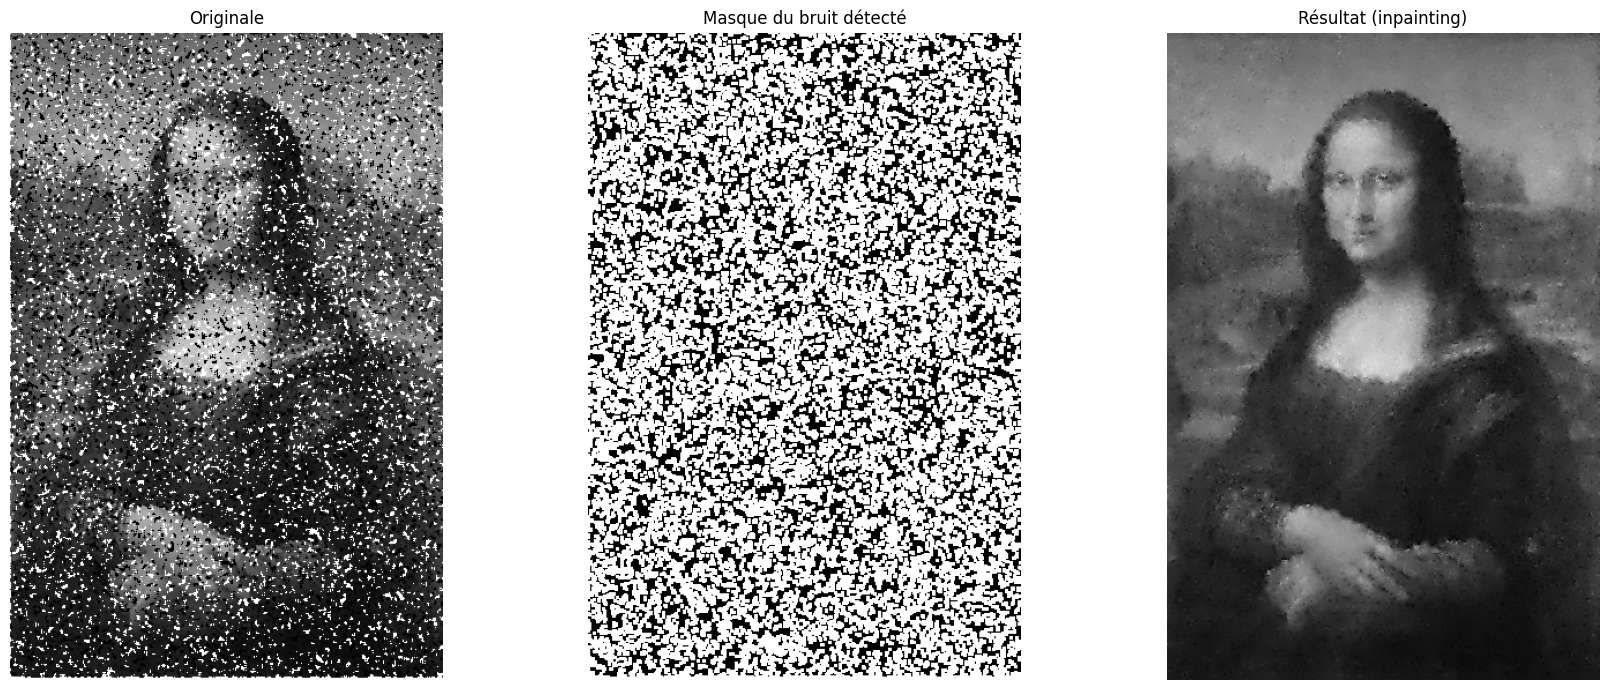

In [9]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread(r"C:\Users\julyc\OneDrive\Bureau\Stage\POC\brief_OpenCV\brief_OpenCV\mona.png")

# 1. Créer un masque des pixels sel et poivre (très blancs ou très noirs)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
mask_white = gray > 245
mask_black = gray < 10
mask = (mask_white | mask_black).astype(np.uint8) * 255

# 2. Dilater le masque légèrement pour couvrir les bords des pixels bruités
mask = cv2.dilate(mask, np.ones((3, 3), np.uint8), iterations=1)

# 3. Inpainting — reconstruit UNIQUEMENT les pixels masqués à partir des voisins
img_denoised = cv2.inpaint(img, mask, inpaintRadius=5, flags=cv2.INPAINT_TELEA)

# 4. Légère accentuation
gaussian = cv2.GaussianBlur(img_denoised, (0, 0), 1.5)
img_sharp = cv2.addWeighted(img_denoised, 1.3, gaussian, -0.3, 0)

# Affichage
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_result_rgb = cv2.cvtColor(img_sharp, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
axes[0].imshow(img_rgb)
axes[0].set_title("Originale")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Masque du bruit détecté")
axes[1].axis("off")

axes[2].imshow(img_result_rgb)
axes[2].set_title("Résultat (inpainting)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

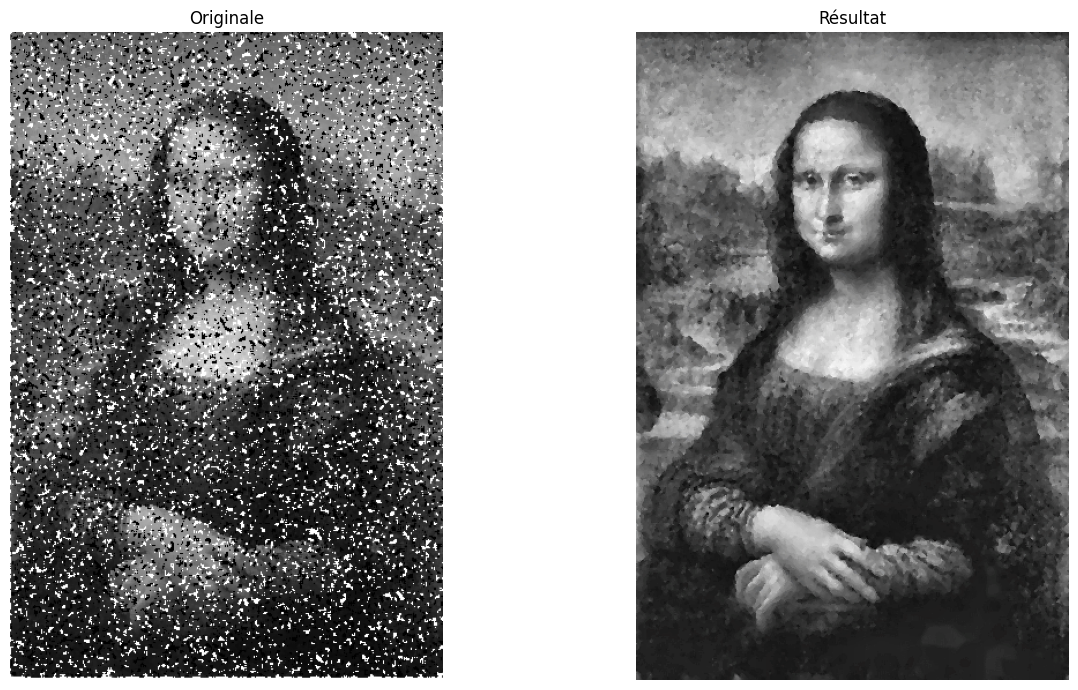

In [10]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread(r"C:\Users\julyc\OneDrive\Bureau\Stage\POC\brief_OpenCV\brief_OpenCV\mona.png")

result = img.copy()

# Inpainting itératif — on traite par couches avec des seuils de plus en plus souples
thresholds = [(250, 5), (240, 15), (230, 25)]

for white_thresh, black_thresh in thresholds:
    gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)
    mask = ((gray > white_thresh) | (gray < black_thresh)).astype(np.uint8) * 255
    if cv2.countNonZero(mask) > 0:
        result = cv2.inpaint(result, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

# Un seul médian léger pour les résidus
result = cv2.medianBlur(result, 3)

# Accentuation CLAHE — bien meilleure que unsharp pour récupérer du contraste local
lab = cv2.cvtColor(result, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
l = clahe.apply(l)
result = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

# Accentuation des contours
gaussian = cv2.GaussianBlur(result, (0, 0), 1)
result = cv2.addWeighted(result, 1.5, gaussian, -0.5, 0)

# Affichage
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
ax1.imshow(img_rgb)
ax1.set_title("Originale")
ax1.axis("off")

ax2.imshow(result_rgb)
ax2.set_title("Résultat")
ax2.axis("off")

plt.tight_layout()
plt.show()